# Exploratory Data Analysis

## Objective
Understand dataset distribution and potential class imbalance before training a classifier.

**Dataset:** [Dishwasher-Safe or Not](https://www.kaggle.com/datasets/anushreesitaramdas/dishwasher-safe-or-not)
**Blog post:** [Stop Guessing About Your Image Dataset: A Practical EDA Guide with Pandas and Matplotlib](https://anushree-das.medium.com/image-dataset-analysis-using-python-libraries-pandas-and-matplotlib-a640e5f59805)

## Key Questions
- Is the dataset balanced across classes?
- Are some sub-classes underrepresented?
- How might imbalance affect model training and evaluation?

## 1. Import Libraries

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Data

We scan the dataset directory recursively and build a DataFrame with three columns:
- `Filename`: image file name
- `Class`: top-level label (`dishwasher-safe` or `not-dishwasher-safe`)
- `Sub_Class`: sub-directory name representing the object type (e.g., spoon, mug)

> **Note:** Set `DATA_DIR` to the root of your dataset before running.

In [13]:
DATA_DIR = "../data/final_data"
positive_images_path = os.path.join(DATA_DIR, 'dishwasher-safe')
negative_images_path = os.path.join(DATA_DIR, 'not-dishwasher-safe')

SUPPORTED_EXTENSIONS = {'JPG', 'jpeg', 'png', 'jpg', 'gif', 'webp'}

In [14]:
def load_data(images_path, class_label):
    """
    Walk a class directory and collect image metadata into a list of records.
    Args:
        images_path (str): Path to the class directory containing sub-class subdirectories.
        class_label (str): Top-level class label to assign to all images in this directory.

    Returns:
        list[dict]: Records with keys 'Filename', 'Class', and 'Sub_Class'.
    """
    records = []
    subdirs = [
        s for s in os.listdir(images_path)
        if os.path.isdir(os.path.join(images_path, s))
    ]
    for subdir in subdirs:
        subdir_path = os.path.join(images_path, subdir)
        with os.scandir(subdir_path) as files:
            for entry in files:
                ext = entry.name.split('.')[-1]
                if entry.is_file() and ext in SUPPORTED_EXTENSIONS:
                    records.append({
                        'Filename': entry.name,
                        'Class': class_label,
                        'Sub_Class': subdir
                    })
    return records

records = load_data(positive_images_path, 'dishwasher-safe')
records += load_data(negative_images_path, 'not-dishwasher-safe')

df = pd.DataFrame(records, columns=['Filename', 'Class', 'Sub_Class'])

print(f"Total images loaded: {len(df)}")
df.head()

Total images loaded: 1237


,Filename,Class,Sub_Class
0,Screen Shot 2023-09-22 at 3.46.27 PM.png,dishwasher-safe,dinner_knife
1,Screen Shot 2023-09-22 at 3.47.19 PM.png,dishwasher-safe,dinner_knife
2,Screen Shot 2023-09-22 at 3.45.26 PM.png,dishwasher-safe,dinner_knife
3,Screen Shot 2023-09-22 at 3.46.50 PM.png,dishwasher-safe,dinner_knife
4,Screen Shot 2023-09-22 at 3.47.44 PM.png,dishwasher-safe,dinner_knife


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Filename   1237 non-null   object
 1   Class      1237 non-null   object
 2   Sub_Class  1237 non-null   object
dtypes: object(3)
memory usage: 29.1+ KB


In [16]:
# Save metadata to CSV for reuse in downstream notebooks
output_csv = '../Data/data.csv'
df.to_csv(output_csv, index=False)
print(f"Saved to {output_csv}")

Saved to ../Data/data.csv


## 3. Data Exploration

### 3.1 Class Distribution

We start at the top level: how many images belong to each of the two classes?

In [17]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nImbalance ratio: {class_counts.max() / class_counts.min():.2f}x")

Class
dishwasher-safe        716
not-dishwasher-safe    521
Name: count, dtype: int64

Imbalance ratio: 1.37x


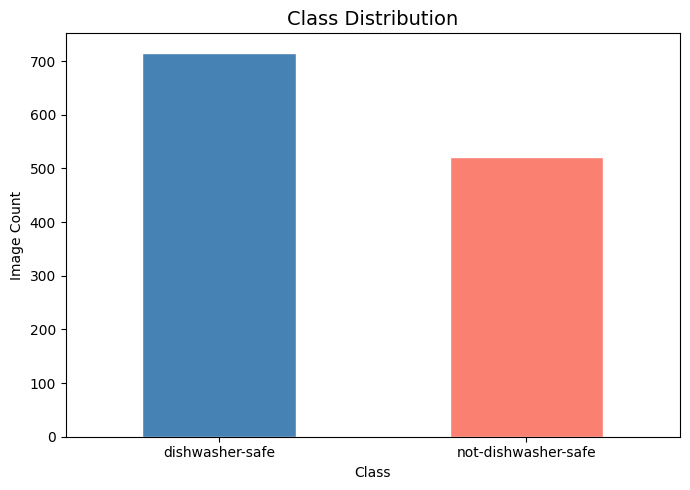

In [19]:
plt.figure(figsize=(7, 5))
class_counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/class_dist.png', dpi=150)
plt.show()

### 3.2 Sub-Class Distribution

The sub-class level is where imbalance tends to be more severe. With 55 sub-classes
spread across ~1,200 images, some categories will have far fewer examples than others.

In [20]:
sub_class_counts = df['Sub_Class'].value_counts()
print(f"Total sub-classes: {len(sub_class_counts)}")
print(f"Largest sub-class: {sub_class_counts.index[0]} ({sub_class_counts.iloc[0]} images)")
print(f"Smallest sub-class: {sub_class_counts.index[-1]} ({sub_class_counts.iloc[-1]} images)")

Total sub-classes: 55
Largest sub-class: mug (51 images)
Smallest sub-class: miscellaneous (2 images)


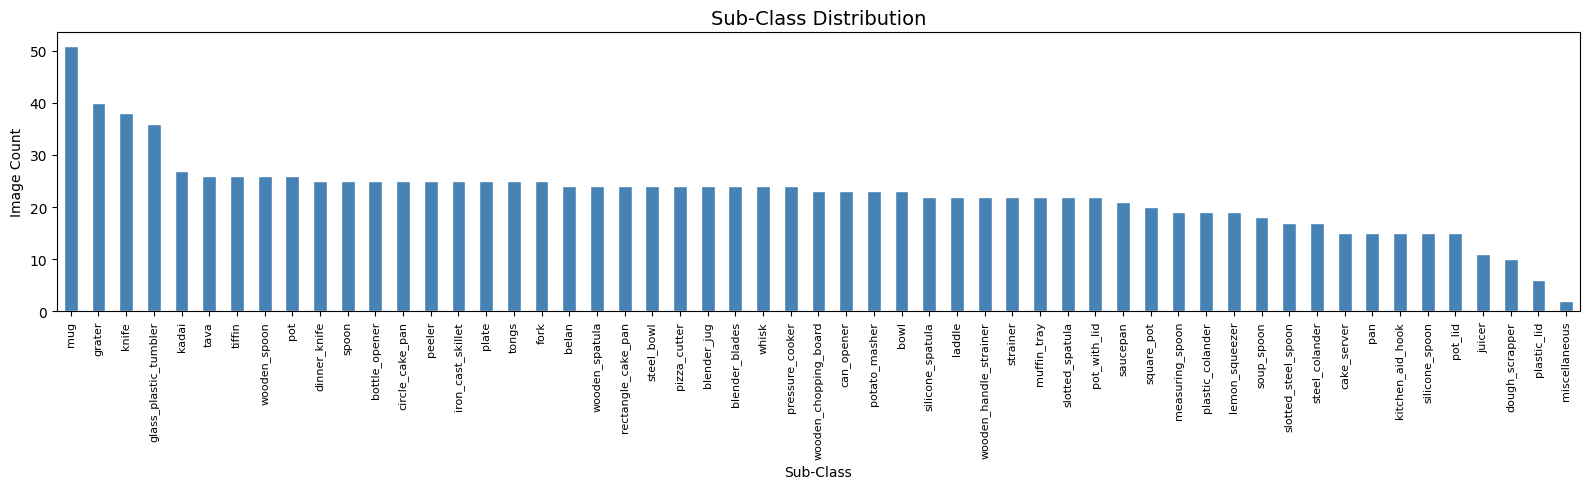

In [21]:
plt.figure(figsize=(16, 5))
sub_class_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Sub-Class Distribution', fontsize=14)
plt.xlabel('Sub-Class')
plt.ylabel('Image Count')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('../images/sub_class_dist.png', dpi=150)
plt.show()

### 3.3 Sub-Classes with Fewer than 20 Images

Sub-classes with very few samples are at highest risk of being poorly learned by a model.
Flagging them now informs decisions about data collection, augmentation, or merging categories.

In [22]:
SAMPLE_THRESHOLD = 20
underrepresented = sub_class_counts[sub_class_counts < SAMPLE_THRESHOLD]
print(f"Sub-classes with fewer than {SAMPLE_THRESHOLD} images: {len(underrepresented)}")
print(underrepresented.to_string())

Sub-classes with fewer than 20 images: 15
Sub_Class
measuring_spoon        19
plastic_colander       19
lemon_squeezer         19
soup_spoon             18
slotted_steel_spoon    17
steel_colander         17
cake_server            15
pan                    15
kitchen_aid_hook       15
silicone_spoon         15
pot_lid                15
juicer                 11
dough_scrapper         10
plastic_lid             6
miscellaneous           2


## 4. Key Insights

**Class level:**
- The dataset contains 716 dishwasher-safe and 521 not-dishwasher-safe images — a moderate 58/42 split.
- This level of imbalance is manageable but worth accounting for during training.

**Sub-class level:**
- With 55 sub-classes across ~1,200 total images, the average is only ~22 images per sub-class.
- The distribution has a long tail: a few sub-classes dominate while many are severely underrepresented.
- Some sub-classes may not have enough data to train on reliably.

**Implications for modeling:**
- Use stratified train/val splits to preserve class ratios
- Apply class weighting or oversampling to handle imbalance
- Evaluate with per-class precision, recall, and F1 — not just accuracy
- Consider merging or dropping sub-classes with fewer than ~15 images

**Next step:** Before committing to labeling, it's worth checking whether the images within each category are visually coherent. The clustering notebook (Clustering_on_Image_Dataset.ipynb) uses VGG16 features and KMeans to find structure in the unlabelled version of this dataset.

---
**Author:** Anushree Das
**LinkedIn:** [anushree-s-das](https://www.linkedin.com/in/anushree-s-das)
**GitHub:** [anushreedas](https://github.com/anushreedas)
**Blog post:** [Image Dataset Analysis using Python Libraries — Pandas and Matplotlib](https://medium.com/@anushreedas.2710/image-dataset-analysis-using-python-libraries-pandas-and-matplotlib-a640e5f59805)